In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

df_beauty = pd.read_json('/content/drive/MyDrive/Dataset/Beauty_5.json', lines=True)

df_cellphones = pd.read_json('/content/drive/MyDrive/Dataset/Cell_Phones_and_Accessories_5.json', lines=True)

df_sports = pd.read_json('/content/drive/MyDrive/Dataset/Sports_and_Outdoors_5.json', lines=True)

In [5]:
print(df_beauty.shape)
print(df_cellphones.shape)
print(df_sports.shape)

print(df_beauty.columns.tolist())

(198502, 9)
(194439, 9)
(296337, 9)
['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime', 'reviewTime']


In [6]:
df_beauty.head(2)

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A1YJEY40YUW4SE,7806397051,Andrea,"[3, 4]",Very oily and creamy. Not at all what I expect...,1,Don't waste your money,1391040000,"01 30, 2014"
1,A60XNB876KYML,7806397051,Jessica H.,"[1, 1]",This palette was a decent price and I was look...,3,OK Palette!,1397779200,"04 18, 2014"


In [7]:
import pandas as pd
import numpy as np

cols = ['reviewText', 'overall']

beauty = df_beauty[cols].copy()
cellphones = df_cellphones[cols].copy()
sports = df_sports[cols].copy()


beauty_sample = beauty.sample(n=12000, random_state=42)
cellphones_sample = cellphones.sample(n=12000, random_state=42)
sports_sample = sports.sample(n=12000, random_state=42)


df = pd.concat([beauty_sample, cellphones_sample, sports_sample], ignore_index=True)


df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
print(df['overall'].value_counts())
print(df.isnull().sum())

(36000, 2)
overall
5    21353
4     7401
3     3595
1     1835
2     1816
Name: count, dtype: int64
reviewText    0
overall       0
dtype: int64


In [8]:
import re
import string
from collections import Counter
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))



def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def tokenize(text):
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]  # remove stopwords
    return tokens

df['cleaned_text'] = df['reviewText'].apply(clean_text)
df['tokens'] = df['cleaned_text'].apply(tokenize)

print("cleaning + stopword removal done")
print(df['tokens'][0])
print("avg tokens per review:", int(df['tokens'].apply(len).mean()))
print("max tokens:", df['tokens'].apply(len).max())
print("min tokens:", df['tokens'].apply(len).min())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


cleaning + stopword removal done
['bling', 'big', 'stone', 'small', 'ones', 'yes', 'different', 'love']
avg tokens per review: 44
max tokens: 2449
min tokens: 0


In [9]:
df = df[df['tokens'].apply(len) > 0].reset_index(drop=True)
print("after dropping empty reviews:", df.shape)

after dropping empty reviews: (35988, 4)


In [10]:

# Step 3: Train/Val/Test Split


from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")


# Step 4: Vocabulary Building (training data only)

MIN_FREQ = 2

word_counts = Counter()
for tokens in train_df['tokens']:
    word_counts.update(tokens)

PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word, count in word_counts.items():
    if count >= MIN_FREQ:
        vocab[word] = len(vocab)

print(f"vocab size: {len(vocab)}")


# Step 5:Numericalization and Padding

MAX_LEN = 128

def encode(tokens, vocab, max_len):
    ids = [vocab.get(t, vocab[UNK_TOKEN]) for t in tokens]
    ids = ids[:max_len]
    ids = ids + [vocab[PAD_TOKEN]] * (max_len - len(ids))
    return ids

train_df['input_ids'] = train_df['tokens'].apply(lambda x: encode(x, vocab, MAX_LEN))
val_df['input_ids'] = val_df['tokens'].apply(lambda x: encode(x, vocab, MAX_LEN))
test_df['input_ids'] = test_df['tokens'].apply(lambda x: encode(x, vocab, MAX_LEN))

print("numericalization + padding done")
print("sample input ids (first 10):", train_df['input_ids'][0][:10])
print("all sequences length 128?", all(len(x) == MAX_LEN for x in train_df['input_ids']))

train: 25191, val: 5398, test: 5399
vocab size: 21109
numericalization + padding done
sample input ids (first 10): [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
all sequences length 128? True


In [11]:

# Label Preparation



def get_sentiment(rating):
    if rating <= 2:
        return 0  # negative
    elif rating == 3:
        return 1  # neutral
    else:
        return 2  # positive


def get_length_bucket(tokens):
    l = len(tokens)
    if l < 20:
        return 0   # short
    elif l <= 60:
        return 1   # medium
    else:
        return 2   # long

for split in [train_df, val_df, test_df]:
    split['sentiment'] = split['overall'].apply(get_sentiment)
    split['length_bucket'] = split['tokens'].apply(get_length_bucket)

print("label distribution - sentiment:")
print(train_df['sentiment'].value_counts())
print("\nlabel distribution - length bucket:")
print(train_df['length_bucket'].value_counts())

label distribution - sentiment:
sentiment
2    20129
0     2573
1     2489
Name: count, dtype: int64

label distribution - length bucket:
length_bucket
1    10921
0     9240
2     5030
Name: count, dtype: int64


# Part A: Encoder Transformer

In [12]:


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("using device:", device)



class ReviewDataset(Dataset):
    def __init__(self, df):
        self.input_ids = torch.tensor(df['input_ids'].tolist(), dtype=torch.long)
        self.sentiment = torch.tensor(df['sentiment'].tolist(), dtype=torch.long)
        self.length_bucket = torch.tensor(df['length_bucket'].tolist(), dtype=torch.long)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'sentiment': self.sentiment[idx],
            'length_bucket': self.length_bucket[idx]
        }

train_dataset = ReviewDataset(train_df)
val_dataset = ReviewDataset(val_df)
test_dataset = ReviewDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("dataloaders ready")
print("train batches:", len(train_loader))

using device: cuda
dataloaders ready
train batches: 394


### Positional Encoding and Multi-Head Self Attention

In [13]:


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return x



class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads


        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.size()


        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)


        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)


        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = F.softmax(scores, dim=-1)
        attn_output = torch.matmul(attn_weights, V)


        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        output = self.W_o(attn_output)
        return output

print("attention classes defined")

attention classes defined


### Encoder Block

In [14]:


class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # attention + residual
        attn_out = self.attention(x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        # feedforward + residual
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x



class EncoderModel(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, ff_dim, num_layers, num_classes_sentiment, num_classes_length, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoding = PositionalEncoding(d_model)
        self.dropout = nn.Dropout(dropout)
        self.layers = nn.ModuleList([
            EncoderBlock(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

        self.sentiment_head = nn.Linear(d_model, num_classes_sentiment)
        self.length_head = nn.Linear(d_model, num_classes_length)

    def forward(self, input_ids, mask=None):
        x = self.embedding(input_ids)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        for layer in self.layers:
            x = layer(x, mask)
        x = self.norm(x)

        cls_output = x[:, 0, :]
        sentiment_logits = self.sentiment_head(cls_output)
        length_logits = self.length_head(cls_output)
        return sentiment_logits, length_logits, cls_output

print("encoder model defined")

encoder model defined


### Model Initialization and Weighted Loss

In [15]:


VOCAB_SIZE = len(vocab)
D_MODEL = 128
NUM_HEADS = 4
FF_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.1
NUM_EPOCHS = 10
LR = 1e-3

model = EncoderModel(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_layers=NUM_LAYERS,
    num_classes_sentiment=3,
    num_classes_length=3,
    dropout=DROPOUT
).to(device)

print("model parameters:", sum(p.numel() for p in model.parameters()))




sentiment_counts = train_df['sentiment'].value_counts().sort_index()
sentiment_weights = 1.0 / torch.tensor(sentiment_counts.values, dtype=torch.float)
sentiment_weights = sentiment_weights / sentiment_weights.sum()
sentiment_weights = sentiment_weights.to(device)


length_counts = train_df['length_bucket'].value_counts().sort_index()
length_weights = 1.0 / torch.tensor(length_counts.values, dtype=torch.float)
length_weights = length_weights / length_weights.sum()
length_weights = length_weights.to(device)

sentiment_criterion = nn.CrossEntropyLoss(weight=sentiment_weights)
length_criterion = nn.CrossEntropyLoss(weight=length_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print("sentiment weights:", sentiment_weights)
print("length weights:", length_weights)

model parameters: 2967942
sentiment weights: tensor([0.4626, 0.4782, 0.0591], device='cuda:0')
length weights: tensor([0.2715, 0.2297, 0.4988], device='cuda:0')


### Training Loop

In [16]:




from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

train_losses = []
val_losses = []

def make_pad_mask(input_ids, pad_idx=0):
    # (batch, 1, 1, seq_len)
    mask = (input_ids != pad_idx).unsqueeze(1).unsqueeze(2)
    return mask

def run_epoch(loader, model, optimizer, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0
    correct_sentiment = 0
    correct_length = 0
    total = 0

    with torch.set_grad_enabled(train):
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            sentiment_labels = batch['sentiment'].to(device)
            length_labels = batch['length_bucket'].to(device)

            mask = make_pad_mask(input_ids)

            sentiment_logits, length_logits, _ = model(input_ids, mask)

            loss_sentiment = sentiment_criterion(sentiment_logits, sentiment_labels)
            loss_length = length_criterion(length_logits, length_labels)
            loss = loss_sentiment + loss_length

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            correct_sentiment += (sentiment_logits.argmax(1) == sentiment_labels).sum().item()
            correct_length += (length_logits.argmax(1) == length_labels).sum().item()
            total += input_ids.size(0)

    avg_loss = total_loss / len(loader)
    sent_acc = correct_sentiment / total
    len_acc = correct_length / total
    return avg_loss, sent_acc, len_acc

# training
for epoch in range(NUM_EPOCHS):
    train_loss, train_sent_acc, train_len_acc = run_epoch(train_loader, model, optimizer, train=True)
    val_loss, val_sent_acc, val_len_acc = run_epoch(val_loader, model, optimizer, train=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"epoch {epoch+1}/{NUM_EPOCHS} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | train sent acc: {train_sent_acc:.4f} | val sent acc: {val_sent_acc:.4f} | train len acc: {train_len_acc:.4f} | val len acc: {val_len_acc:.4f}")

epoch 1/10 | train loss: 1.1562 | val loss: 1.0422 | train sent acc: 0.4878 | val sent acc: 0.4909 | train len acc: 0.9573 | val len acc: 0.9796
epoch 2/10 | train loss: 0.9664 | val loss: 0.9677 | train sent acc: 0.6118 | val sent acc: 0.6686 | train len acc: 0.9865 | val len acc: 0.9839
epoch 3/10 | train loss: 0.8604 | val loss: 0.9656 | train sent acc: 0.6600 | val sent acc: 0.5469 | train len acc: 0.9886 | val len acc: 0.9846
epoch 4/10 | train loss: 0.7795 | val loss: 0.9764 | train sent acc: 0.6906 | val sent acc: 0.6814 | train len acc: 0.9904 | val len acc: 0.9859
epoch 5/10 | train loss: 0.6765 | val loss: 0.9927 | train sent acc: 0.7254 | val sent acc: 0.6778 | train len acc: 0.9917 | val len acc: 0.9861
epoch 6/10 | train loss: 0.5738 | val loss: 1.1326 | train sent acc: 0.7590 | val sent acc: 0.6715 | train len acc: 0.9920 | val len acc: 0.9850
epoch 7/10 | train loss: 0.5154 | val loss: 1.0967 | train sent acc: 0.7777 | val sent acc: 0.6551 | train len acc: 0.9922 | val l

### Retrain with Early Stopping + Save Best Model

In [17]:



model = EncoderModel(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_layers=NUM_LAYERS,
    num_classes_sentiment=3,
    num_classes_length=3,
    dropout=DROPOUT
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses = []
val_losses = []

best_val_loss = float('inf')
patience = 3
patience_counter = 0
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_sent_acc, train_len_acc = run_epoch(train_loader, model, optimizer, train=True)
    val_loss, val_sent_acc, val_len_acc = run_epoch(val_loader, model, optimizer, train=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"epoch {epoch+1}/{NUM_EPOCHS} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | train sent acc: {train_sent_acc:.4f} | val sent acc: {val_sent_acc:.4f} | train len acc: {train_len_acc:.4f} | val len acc: {val_len_acc:.4f}")


    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), '/content/drive/MyDrive/Dataset/best_encoder.pt')
        print(f"  --> best model saved at epoch {epoch+1}")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"early stopping at epoch {epoch+1}, best was epoch {best_epoch}")
            break

print("training done, best epoch:", best_epoch)

epoch 1/10 | train loss: 1.1589 | val loss: 1.0423 | train sent acc: 0.4684 | val sent acc: 0.6517 | train len acc: 0.9607 | val len acc: 0.9872
  --> best model saved at epoch 1
epoch 2/10 | train loss: 0.9627 | val loss: 0.9533 | train sent acc: 0.6127 | val sent acc: 0.4911 | train len acc: 0.9860 | val len acc: 0.9885
  --> best model saved at epoch 2
epoch 3/10 | train loss: 0.8595 | val loss: 0.9536 | train sent acc: 0.6620 | val sent acc: 0.6747 | train len acc: 0.9910 | val len acc: 0.9885
epoch 4/10 | train loss: 0.7616 | val loss: 0.9684 | train sent acc: 0.7043 | val sent acc: 0.6260 | train len acc: 0.9920 | val len acc: 0.9861
epoch 5/10 | train loss: 0.6716 | val loss: 1.0173 | train sent acc: 0.7374 | val sent acc: 0.6213 | train len acc: 0.9927 | val len acc: 0.9850
early stopping at epoch 5, best was epoch 2
training done, best epoch: 2


### Load Best Model and Test Evaluation

In [18]:


from sklearn.metrics import classification_report

model.load_state_dict(torch.load('/content/drive/MyDrive/Dataset/best_encoder.pt'))
model.eval()

all_sentiment_preds = []
all_sentiment_labels = []
all_length_preds = []
all_length_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        sentiment_labels = batch['sentiment'].to(device)
        length_labels = batch['length_bucket'].to(device)

        mask = make_pad_mask(input_ids)
        sentiment_logits, length_logits, _ = model(input_ids, mask)

        all_sentiment_preds.extend(sentiment_logits.argmax(1).cpu().numpy())
        all_sentiment_labels.extend(sentiment_labels.cpu().numpy())
        all_length_preds.extend(length_logits.argmax(1).cpu().numpy())
        all_length_labels.extend(length_labels.cpu().numpy())

print("Sentiment Classification Report: ")
print(classification_report(all_sentiment_labels, all_sentiment_preds, target_names=['negative', 'neutral', 'positive']))

print("Length Bucket Classification Report: ")
print(classification_report(all_length_labels, all_length_preds, target_names=['short', 'medium', 'long']))

Sentiment Classification Report: 
              precision    recall  f1-score   support

    negative       0.35      0.57      0.43       548
     neutral       0.15      0.66      0.24       546
    positive       0.96      0.46      0.62      4305

    accuracy                           0.49      5399
   macro avg       0.48      0.56      0.43      5399
weighted avg       0.81      0.49      0.56      5399

Length Bucket Classification Report: 
              precision    recall  f1-score   support

       short       0.99      0.99      0.99      1994
      medium       0.99      0.99      0.99      2312
        long       0.99      0.99      0.99      1093

    accuracy                           0.99      5399
   macro avg       0.99      0.99      0.99      5399
weighted avg       0.99      0.99      0.99      5399



### Learning Curves

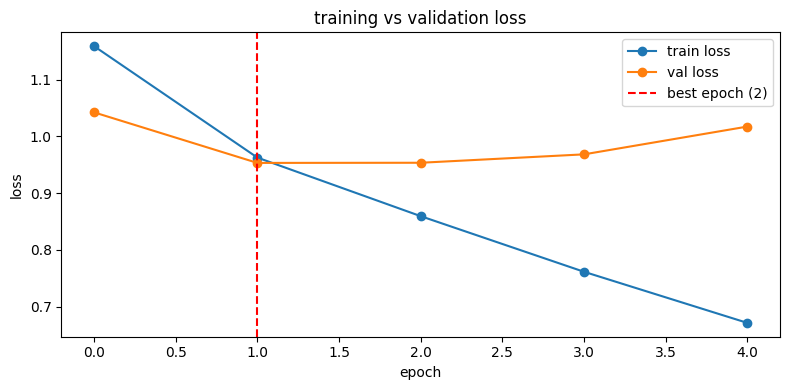

learning curve saved


In [19]:



plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='train loss', marker='o')
plt.plot(val_losses, label='val loss', marker='o')
plt.axvline(x=best_epoch-1, color='red', linestyle='--', label=f'best epoch ({best_epoch})')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('training vs validation loss')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dataset/learning_curve.png')
plt.show()
print("learning curve saved")

### Sentiment Confusion Matrix & Length Bucket Confusion Matrix & Per Class F1 Score Comparison

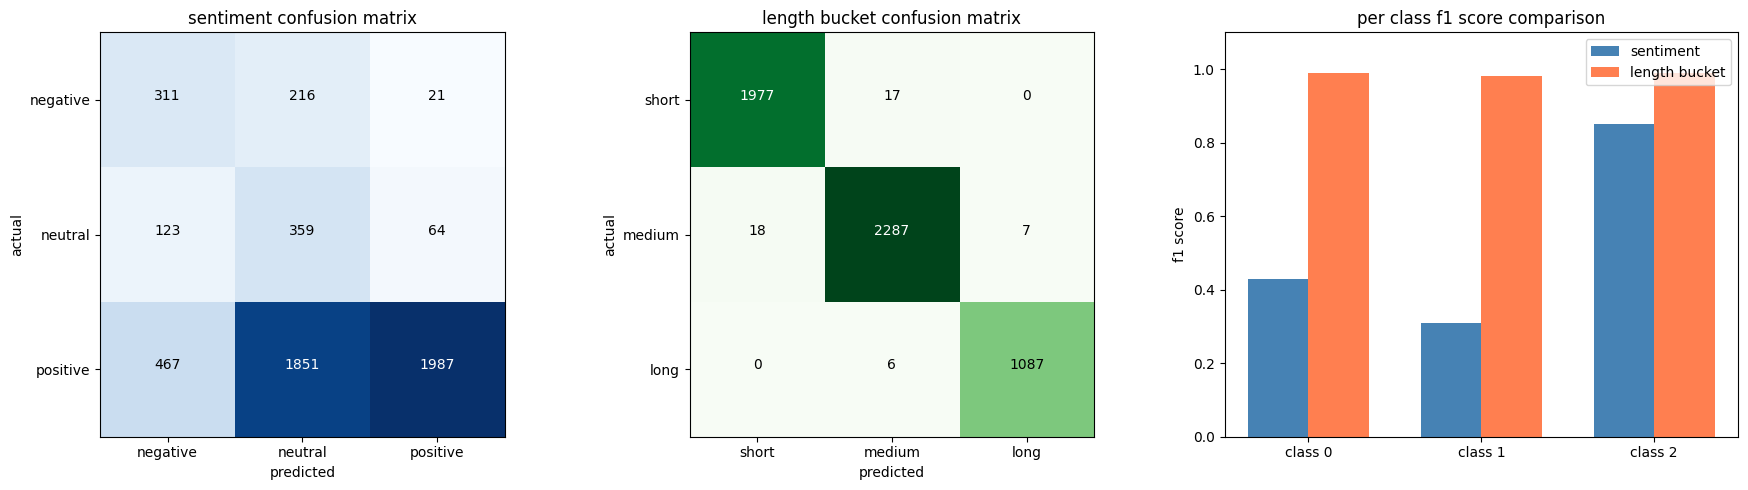

evaluation plots saved


In [20]:
from sklearn.metrics import confusion_matrix
import itertools

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


cm_sent = confusion_matrix(all_sentiment_labels, all_sentiment_preds)
im1 = axes[0].imshow(cm_sent, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title('sentiment confusion matrix')
axes[0].set_xticks([0,1,2])
axes[0].set_yticks([0,1,2])
axes[0].set_xticklabels(['negative', 'neutral', 'positive'])
axes[0].set_yticklabels(['negative', 'neutral', 'positive'])
axes[0].set_xlabel('predicted')
axes[0].set_ylabel('actual')
for i, j in itertools.product(range(cm_sent.shape[0]), range(cm_sent.shape[1])):
    axes[0].text(j, i, cm_sent[i, j], horizontalalignment='center', color='white' if cm_sent[i, j] > cm_sent.max()/2 else 'black')



cm_len = confusion_matrix(all_length_labels, all_length_preds)
im2 = axes[1].imshow(cm_len, interpolation='nearest', cmap=plt.cm.Greens)
axes[1].set_title('length bucket confusion matrix')
axes[1].set_xticks([0,1,2])
axes[1].set_yticks([0,1,2])
axes[1].set_xticklabels(['short', 'medium', 'long'])
axes[1].set_yticklabels(['short', 'medium', 'long'])
axes[1].set_xlabel('predicted')
axes[1].set_ylabel('actual')
for i, j in itertools.product(range(cm_len.shape[0]), range(cm_len.shape[1])):
    axes[1].text(j, i, cm_len[i, j], horizontalalignment='center', color='white' if cm_len[i, j] > cm_len.max()/2 else 'black')


sentiment_f1 = [0.43, 0.31, 0.85]
length_f1 = [0.99, 0.98, 0.99]
x = np.arange(3)
width = 0.35
axes[2].bar(x - width/2, sentiment_f1, width, label='sentiment', color='steelblue')
axes[2].bar(x + width/2, length_f1, width, label='length bucket', color='coral')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['class 0', 'class 1', 'class 2'])
axes[2].set_ylabel('f1 score')
axes[2].set_title('per class f1 score comparison')
axes[2].legend()
axes[2].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dataset/evaluation_plots.png')
plt.show()
print("evaluation plots saved")

In [21]:


import os
os.makedirs('/content/drive/MyDrive/Dataset/results', exist_ok=True)

model.eval()
all_embeddings = []

with torch.no_grad():
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        mask = make_pad_mask(input_ids)
        _, _, cls_output = model(input_ids, mask)
        all_embeddings.append(cls_output.cpu().numpy())

all_embeddings = np.vstack(all_embeddings)
np.save('/content/drive/MyDrive/Dataset/results/train_embeddings.npy', all_embeddings)


train_sentiments = train_df['sentiment'].values
train_lengths = train_df['length_bucket'].values
train_texts = train_df['cleaned_text'].values

np.save('/content/drive/MyDrive/Dataset/results/train_sentiments.npy', train_sentiments)
np.save('/content/drive/MyDrive/Dataset/results/train_lengths.npy', train_lengths)
np.save('/content/drive/MyDrive/Dataset/results/train_texts.npy', train_texts)

print("embeddings shape:", all_embeddings.shape)
print("all files saved to results/")

embeddings shape: (25191, 128)
all files saved to results/


# Part B: Retrieval Module

In [22]:

train_embeddings = np.load('/content/drive/MyDrive/Dataset/results/train_embeddings.npy')
train_sentiments = np.load('/content/drive/MyDrive/Dataset/results/train_sentiments.npy')
train_lengths = np.load('/content/drive/MyDrive/Dataset/results/train_lengths.npy')
train_texts = np.load('/content/drive/MyDrive/Dataset/results/train_texts.npy', allow_pickle=True)

print("loaded embeddings shape:", train_embeddings.shape)
print("loaded sentiments shape:", train_sentiments.shape)
print("loaded texts shape:", train_texts.shape)

loaded embeddings shape: (25191, 128)
loaded sentiments shape: (25191,)
loaded texts shape: (25191,)


### Retrieval Function (Cosine Similarity)

In [23]:



def cosine_similarity_matrix(query_vec, corpus_matrix):

    query_norm = query_vec / (np.linalg.norm(query_vec) + 1e-8)
    corpus_norm = corpus_matrix / (np.linalg.norm(corpus_matrix, axis=1, keepdims=True) + 1e-8)
    similarities = corpus_norm @ query_norm
    return similarities

def retrieve_topk(query_embedding, corpus_embeddings, corpus_texts, corpus_sentiments, k=3):
    similarities = cosine_similarity_matrix(query_embedding, corpus_embeddings)
    top_k_indices = np.argsort(similarities)[::-1][:k]
    results = []
    for idx in top_k_indices:
        results.append({
            'text': corpus_texts[idx],
            'sentiment': corpus_sentiments[idx],
            'similarity': similarities[idx]
        })
    return results

print("retrieval function defined")

retrieval function defined


###  Get Test Embeddings and Show Retrieval Examples

In [24]:


model.eval()
test_embeddings = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        mask = make_pad_mask(input_ids)
        _, _, cls_output = model(input_ids, mask)
        test_embeddings.append(cls_output.cpu().numpy())

test_embeddings = np.vstack(test_embeddings)
print("test embeddings shape:", test_embeddings.shape)


label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

for i in [0, 5, 10]:
    query_text = test_df['cleaned_text'].iloc[i]
    query_sentiment = test_df['sentiment'].iloc[i]
    query_embedding = test_embeddings[i]

    print(f"\n{'='*60}")
    print(f"QUERY REVIEW: {query_text[:150]}")
    print(f"QUERY SENTIMENT: {label_map[query_sentiment]}")
    print(f"\nTOP 3 RETRIEVED:")

    results = retrieve_topk(query_embedding, train_embeddings, train_texts, train_sentiments, k=3)
    for j, r in enumerate(results):
        print(f"  [{j+1}] similarity: {r['similarity']:.4f} | sentiment: {label_map[int(r['sentiment'])]} | text: {r['text'][:100]}")

test embeddings shape: (5399, 128)

QUERY REVIEW: i have mixed feelings a lot of thought went in to the presentation of this little speaker the packaging is overthetop more money should have gone in t
QUERY SENTIMENT: neutral

TOP 3 RETRIEVED:
  [1] similarity: 0.9740 | sentiment: positive | text: simple kind to skin moisturizing facial wash is a wonderful product the ounce tube will last me a lo
  [2] similarity: 0.9621 | sentiment: positive | text: i titled this short review as i did because i have an older version of basically the same type of sl
  [3] similarity: 0.9156 | sentiment: positive | text: works as a splitter but the usb ports dont seem to be putting out as much power as id have thought b

QUERY REVIEW: i bought this cable for my wifes galaxy note i was amazed at the size of it its a heavy duty cord and it doesnt take long to charge her phone up she l
QUERY SENTIMENT: positive

TOP 3 RETRIEVED:
  [1] similarity: 0.9899 | sentiment: positive | text: one of the lesser cases

### Effect of K on Retrieval

In [25]:


print("analyzing effect of k on retrieval...\n")

k_values = [1, 3, 5, 7]
label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

# pick one query for k analysis
query_idx = 0
query_embedding = test_embeddings[query_idx]
query_sentiment = test_df['sentiment'].iloc[query_idx]

for k in k_values:
    results = retrieve_topk(query_embedding, train_embeddings, train_texts, train_sentiments, k=k)
    sentiment_match = sum(1 for r in results if int(r['sentiment']) == query_sentiment)
    avg_sim = np.mean([r['similarity'] for r in results])
    print(f"k={k} | avg similarity: {avg_sim:.4f} | sentiment match: {sentiment_match}/{k}")



np.save('/content/drive/MyDrive/Dataset/results/test_embeddings.npy', test_embeddings)
print("\ntest embeddings saved")


analyzing effect of k on retrieval...

k=1 | avg similarity: 0.9740 | sentiment match: 0/1
k=3 | avg similarity: 0.9505 | sentiment match: 0/3
k=5 | avg similarity: 0.9350 | sentiment match: 0/5
k=7 | avg similarity: 0.9282 | sentiment match: 0/7

test embeddings saved


###  Retrieval Quality Analysis(full test set)

In [26]:


k = 3
sentiment_match_counts = []

for i in range(len(test_embeddings)):
    query_embedding = test_embeddings[i]
    query_sentiment = test_df['sentiment'].iloc[i]
    results = retrieve_topk(query_embedding, train_embeddings, train_texts, train_sentiments, k=k)
    match = sum(1 for r in results if int(r['sentiment']) == query_sentiment)
    sentiment_match_counts.append(match / k)

avg_match = np.mean(sentiment_match_counts)
print(f"average sentiment match rate across test set (k=3): {avg_match:.4f}")

average sentiment match rate across test set (k=3): 0.6575


# Part C:Decoder

In [27]:



BOS_TOKEN = '<BOS>'
EOS_TOKEN = '<EOS>'


vocab[BOS_TOKEN] = len(vocab)
vocab[EOS_TOKEN] = len(vocab)


idx2word = {idx: word for word, idx in vocab.items()}

VOCAB_SIZE = len(vocab)
print("updated vocab size:", VOCAB_SIZE)
print("BOS index:", vocab[BOS_TOKEN])
print("EOS index:", vocab[EOS_TOKEN])

updated vocab size: 21111
BOS index: 21109
EOS index: 21110


### Decoder Input Template Construction

In [28]:


MAX_DEC_LEN = 64
sentiment_str = {0: 'negative', 1: 'neutral', 2: 'positive'}
length_str = {0: 'short', 1: 'medium', 2: 'long'}

def build_decoder_input(review_text, sentiment_label, length_label, retrieved_reviews, max_len=MAX_DEC_LEN):

    retrieved_str = ' '.join([r['text'][:50] for r in retrieved_reviews])
    template = (
        f"review {review_text[:80]} "
        f"sentiment {sentiment_str[sentiment_label]} "
        f"length {length_str[length_label]} "
        f"similar {retrieved_str}"
    )

    tokens = tokenize(clean_text(template))
    ids = [vocab[BOS_TOKEN]] + [vocab.get(t, vocab[UNK_TOKEN]) for t in tokens]
    ids = ids[:max_len]
    ids = ids + [vocab[PAD_TOKEN]] * (max_len - len(ids))
    return ids


test_review = test_df['cleaned_text'].iloc[0]
test_sentiment = test_df['sentiment'].iloc[0]
test_length = test_df['length_bucket'].iloc[0]
test_retrieved = retrieve_topk(test_embeddings[0], train_embeddings, train_texts, train_sentiments, k=3)

sample_input = build_decoder_input(test_review, test_sentiment, test_length, test_retrieved)
print("sample decoder input length:", len(sample_input))
print("first 15 token ids:", sample_input[:15])

sample decoder input length: 64
first 15 token ids: [21109, 723, 2469, 13652, 504, 85, 914, 7887, 1, 1, 2218, 1130, 8, 985, 1598]


###  Decoder Dataset

In [31]:


def batch_retrieve_topk(query_embeddings, corpus_embeddings, corpus_texts, corpus_sentiments, k=3):

    corpus_norm = corpus_embeddings / (np.linalg.norm(corpus_embeddings, axis=1, keepdims=True) + 1e-8)
    results_all = []
    for i in range(len(query_embeddings)):
        query_norm = query_embeddings[i] / (np.linalg.norm(query_embeddings[i]) + 1e-8)
        sims = corpus_norm @ query_norm
        top_k_indices = np.argsort(sims)[::-1][:k]
        results = [{'text': corpus_texts[idx], 'sentiment': corpus_sentiments[idx], 'similarity': sims[idx]} for idx in top_k_indices]
        results_all.append(results)
    return results_all

print("precomputing train retrievals...")
train_retrievals = batch_retrieve_topk(train_embeddings, train_embeddings, train_texts, train_sentiments, k=3)
print("precomputing val retrievals...")
val_retrievals = batch_retrieve_topk(test_embeddings[:len(val_df)], train_embeddings, train_texts, train_sentiments, k=3)
print("precomputing test retrievals...")
test_retrievals = batch_retrieve_topk(test_embeddings, train_embeddings, train_texts, train_sentiments, k=3)
print("all retrievals done")

precomputing train retrievals...
precomputing val retrievals...
precomputing test retrievals...
all retrievals done


In [34]:


sentiment_str = {0: 'negative', 1: 'neutral', 2: 'positive'}
length_str = {0: 'short', 1: 'medium', 2: 'long'}

def make_explanation(row):
    sent = sentiment_str[row['sentiment']]
    length = length_str[row['length_bucket']]
    if row['sentiment'] == 2:
        return f"this review is {sent} because the customer expressed satisfaction with the product it is a {length} review"
    elif row['sentiment'] == 0:
        return f"this review is {sent} because the customer expressed dissatisfaction with the product it is a {length} review"
    else:
        return f"this review is {sent} because the customer had mixed feelings about the product it is a {length} review"

for split in [train_df, val_df, test_df]:
    split['explanation'] = split.apply(make_explanation, axis=1)

print("explanations created")
print(train_df['explanation'].iloc[0])

explanations created
this review is neutral because the customer had mixed feelings about the product it is a long review


In [35]:


class DecoderDatasetV2(Dataset):
    def __init__(self, df, retrievals, max_input=48, max_exp=16):
        self.samples = []
        for i in range(len(df)):
            review_text = df['cleaned_text'].iloc[i]
            sentiment_label = df['sentiment'].iloc[i]
            length_label = df['length_bucket'].iloc[i]
            explanation = df['explanation'].iloc[i]
            retrieved = retrievals[i]

            retrieved_str = ' '.join([r['text'][:30] for r in retrieved])
            context = (
                f"review {review_text[:60]} "
                f"sentiment {sentiment_str[sentiment_label]} "
                f"length {length_str[length_label]} "
                f"similar {retrieved_str}"
            )
            context_tokens = [vocab[BOS_TOKEN]] + [vocab.get(t, vocab[UNK_TOKEN]) for t in tokenize(clean_text(context))]
            context_tokens = context_tokens[:max_input]
            context_tokens += [vocab[PAD_TOKEN]] * (max_input - len(context_tokens))

            exp_tokens = [vocab.get(t, vocab[UNK_TOKEN]) for t in tokenize(explanation)]
            exp_tokens = exp_tokens + [vocab[EOS_TOKEN]]
            exp_tokens = exp_tokens[:max_exp]
            exp_tokens += [vocab[PAD_TOKEN]] * (max_exp - len(exp_tokens))

            full_seq = context_tokens + exp_tokens
            self.samples.append(full_seq)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ids = self.samples[idx]
        input_ids = torch.tensor(ids[:-1], dtype=torch.long)
        target_ids = torch.tensor(ids[1:], dtype=torch.long)
        return input_ids, target_ids

print("building decoder datasets...")
train_dec_dataset = DecoderDatasetV2(train_df, train_retrievals)
val_dec_dataset = DecoderDatasetV2(val_df, val_retrievals)
test_dec_dataset = DecoderDatasetV2(test_df, test_retrievals)

train_dec_loader = DataLoader(train_dec_dataset, batch_size=64, shuffle=True)
val_dec_loader = DataLoader(val_dec_dataset, batch_size=64, shuffle=False)
test_dec_loader = DataLoader(test_dec_dataset, batch_size=64, shuffle=False)

print("done, sequence length:", len(train_dec_dataset.samples[0]))

building decoder datasets...
done, sequence length: 64


### Masked Multi-Head Self Attention AND Full Decoder Model

In [36]:


class MaskedMultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)


        causal_mask = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0).unsqueeze(0).to(x.device)
        scores = scores.masked_fill(causal_mask == 0, -1e9)

        attn_weights = F.softmax(scores, dim=-1)
        attn_output = torch.matmul(attn_weights, V)

        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        output = self.W_o(attn_output)
        return output



class DecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attention = MaskedMultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_out = self.attention(x)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x



class DecoderModel(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, ff_dim, num_layers, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoding = PositionalEncoding(d_model, max_len=MAX_DEC_LEN)
        self.dropout = nn.Dropout(dropout)
        self.layers = nn.ModuleList([
            DecoderBlock(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.output_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        logits = self.output_head(x)
        return logits

print("decoder model defined")

decoder model defined


### Decoder Initialization and Training

In [38]:
import os
os.makedirs('/content/drive/MyDrive/Dataset/models', exist_ok=True)
os.makedirs('/content/drive/MyDrive/Dataset/results', exist_ok=True)
print("directories created")

directories created


In [39]:


decoder = DecoderModel(
    vocab_size=VOCAB_SIZE,
    d_model=128,
    num_heads=4,
    ff_dim=256,
    num_layers=2,
    dropout=0.1
).to(device)

print("decoder parameters:", sum(p.numel() for p in decoder.parameters()))

dec_optimizer = torch.optim.Adam(decoder.parameters(), lr=1e-3)
dec_criterion = nn.CrossEntropyLoss(ignore_index=0)


dec_train_losses = []
dec_val_losses = []
best_dec_val_loss = float('inf')
dec_patience = 3
dec_patience_counter = 0
best_dec_epoch = 0

NUM_DEC_EPOCHS = 10

for epoch in range(NUM_DEC_EPOCHS):

    decoder.train()
    total_train_loss = 0
    for input_ids, target_ids in train_dec_loader:
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)

        logits = decoder(input_ids)
        loss = dec_criterion(logits.reshape(-1, VOCAB_SIZE), target_ids.reshape(-1))

        dec_optimizer.zero_grad()
        loss.backward()
        dec_optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_dec_loader)


    decoder.eval()
    total_val_loss = 0
    with torch.no_grad():
        for input_ids, target_ids in val_dec_loader:
            input_ids = input_ids.to(device)
            target_ids = target_ids.to(device)
            logits = decoder(input_ids)
            loss = dec_criterion(logits.reshape(-1, VOCAB_SIZE), target_ids.reshape(-1))
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_dec_loader)
    dec_train_losses.append(avg_train_loss)
    dec_val_losses.append(avg_val_loss)

    print(f"epoch {epoch+1}/{NUM_DEC_EPOCHS} | train loss: {avg_train_loss:.4f} | val loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_dec_val_loss:
        best_dec_val_loss = avg_val_loss
        best_dec_epoch = epoch + 1
        torch.save(decoder.state_dict(), '/content/drive/MyDrive/Dataset/models/best_decoder.pt')
        print(f"  --> best decoder saved at epoch {epoch+1}")
        dec_patience_counter = 0
    else:
        dec_patience_counter += 1
        if dec_patience_counter >= dec_patience:
            print(f"early stopping at epoch {epoch+1}, best was epoch {best_dec_epoch}")
            break

print("decoder training done")

decoder parameters: 5690743
epoch 1/10 | train loss: 3.9396 | val loss: 3.4892
  --> best decoder saved at epoch 1
epoch 2/10 | train loss: 3.2867 | val loss: 3.3628
  --> best decoder saved at epoch 2
epoch 3/10 | train loss: 2.9608 | val loss: 3.3319
  --> best decoder saved at epoch 3
epoch 4/10 | train loss: 2.7371 | val loss: 3.3656
epoch 5/10 | train loss: 2.5903 | val loss: 3.4011
epoch 6/10 | train loss: 2.4852 | val loss: 3.4170
early stopping at epoch 6, best was epoch 3
decoder training done


### Load Best Decoder and  Compute Perplexity

In [40]:


decoder.load_state_dict(torch.load('/content/drive/MyDrive/Dataset/models/best_decoder.pt'))
decoder.eval()

total_loss = 0
total_tokens = 0

with torch.no_grad():
    for input_ids, target_ids in test_dec_loader:
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)

        logits = decoder(input_ids)


        mask = (target_ids != 0)
        loss = dec_criterion(logits.reshape(-1, VOCAB_SIZE), target_ids.reshape(-1))
        total_loss += loss.item() * mask.sum().item()
        total_tokens += mask.sum().item()

avg_loss = total_loss / total_tokens
perplexity = math.exp(avg_loss)
print(f"test perplexity: {perplexity:.4f}")

test perplexity: 28.2241


### Autoregressive Generation

In [44]:


def generate_explanation(review_text, sentiment_label, length_label, retrieved, max_gen=15):
    decoder.eval()


    retrieved_str = ' '.join([r['text'][:30] for r in retrieved])
    context = (
        f"review {review_text[:60]} "
        f"sentiment {sentiment_str[sentiment_label]} "
        f"length {length_str[length_label]} "
        f"similar {retrieved_str}"
    )
    context_tokens = [vocab[BOS_TOKEN]] + [vocab.get(t, vocab[UNK_TOKEN]) for t in tokenize(clean_text(context))]
    context_tokens = context_tokens[:48]
    context_tokens += [vocab[PAD_TOKEN]] * (48 - len(context_tokens))

    input_tensor = torch.tensor(context_tokens, dtype=torch.long).unsqueeze(0).to(device)

    generated = []
    with torch.no_grad():
        for _ in range(max_gen):
            logits = decoder(input_tensor)

            next_token = logits[0, -1, :].argmax(-1).item()
            if next_token == vocab[EOS_TOKEN] or next_token == vocab[PAD_TOKEN]:
                break
            generated.append(next_token)
            next_token_tensor = torch.tensor([[next_token]], dtype=torch.long).to(device)
            input_tensor = torch.cat([input_tensor, next_token_tensor], dim=1)

    words = [idx2word.get(idx, UNK_TOKEN) for idx in generated]
    return ' '.join(words)



print(" Generated Explanation Examples: \n")
sample_indices = [0, 10, 50, 100, 200]

for i, idx in enumerate(sample_indices):
    review_text = test_df['cleaned_text'].iloc[idx]
    sentiment_label = test_df['sentiment'].iloc[idx]
    length_label = test_df['length_bucket'].iloc[idx]
    retrieved = test_retrievals[idx]
    explanation = generate_explanation(review_text, sentiment_label, length_label, retrieved)

    print(f"Example {i+1}")
    print(f"Review    : {review_text[:120]}")
    print(f"Sentiment : {sentiment_str[sentiment_label]}")
    print(f"Generated : {explanation}")
    print()

 Generated Explanation Examples: 

Example 1
Review    : i have mixed feelings a lot of thought went in to the presentation of this little speaker the packaging is overthetop mo
Sentiment : neutral
Generated : review neutral customer mixed feelings product long review

Example 2
Review    : these little bags are slightly padded to protect those little bottles and jars i always seem to have leaks but these bag
Sentiment : positive
Generated : review positive customer expressed satisfaction product medium review

Example 3
Review    : i ordered two of the flower power caps and while cute looking i cannot recommend them i have a wide head and long hair t
Sentiment : negative
Generated : review negative customer expressed dissatisfaction product long review

Example 4
Review    : good knife but just not the same as its big brother i have the griptilian which i really like but it is fairly large to 
Sentiment : positive
Generated : review positive customer expressed satisfaction product lon

### Ablation Study: With vs Without Retrieval

In [45]:


class DecoderDatasetNoRAG(Dataset):
    def __init__(self, df, max_input=48, max_exp=16):
        self.samples = []
        for i in range(len(df)):
            review_text = df['cleaned_text'].iloc[i]
            sentiment_label = df['sentiment'].iloc[i]
            length_label = df['length_bucket'].iloc[i]
            explanation = df['explanation'].iloc[i]


            context = (
                f"review {review_text[:60]} "
                f"sentiment {sentiment_str[sentiment_label]} "
                f"length {length_str[length_label]}"
            )
            context_tokens = [vocab[BOS_TOKEN]] + [vocab.get(t, vocab[UNK_TOKEN]) for t in tokenize(clean_text(context))]
            context_tokens = context_tokens[:max_input]
            context_tokens += [vocab[PAD_TOKEN]] * (max_input - len(context_tokens))

            exp_tokens = [vocab.get(t, vocab[UNK_TOKEN]) for t in tokenize(explanation)]
            exp_tokens = exp_tokens + [vocab[EOS_TOKEN]]
            exp_tokens = exp_tokens[:max_exp]
            exp_tokens += [vocab[PAD_TOKEN]] * (max_exp - len(exp_tokens))

            full_seq = context_tokens + exp_tokens
            self.samples.append(full_seq)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ids = self.samples[idx]
        input_ids = torch.tensor(ids[:-1], dtype=torch.long)
        target_ids = torch.tensor(ids[1:], dtype=torch.long)
        return input_ids, target_ids


print("building no-rag datasets...")
train_norag = DecoderDatasetNoRAG(train_df)
val_norag = DecoderDatasetNoRAG(val_df)
test_norag = DecoderDatasetNoRAG(test_df)

train_norag_loader = DataLoader(train_norag, batch_size=64, shuffle=True)
val_norag_loader = DataLoader(val_norag, batch_size=64, shuffle=False)
test_norag_loader = DataLoader(test_norag, batch_size=64, shuffle=False)

decoder_norag = DecoderModel(
    vocab_size=VOCAB_SIZE,
    d_model=128,
    num_heads=4,
    ff_dim=256,
    num_layers=2,
    dropout=0.1
).to(device)

norag_optimizer = torch.optim.Adam(decoder_norag.parameters(), lr=1e-3)
best_norag_val_loss = float('inf')

print("training no-rag baseline...")
for epoch in range(10):
    decoder_norag.train()
    total_train_loss = 0
    for input_ids, target_ids in train_norag_loader:
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)
        logits = decoder_norag(input_ids)
        loss = dec_criterion(logits.reshape(-1, VOCAB_SIZE), target_ids.reshape(-1))
        norag_optimizer.zero_grad()
        loss.backward()
        norag_optimizer.step()
        total_train_loss += loss.item()

    decoder_norag.eval()
    total_val_loss = 0
    with torch.no_grad():
        for input_ids, target_ids in val_norag_loader:
            input_ids = input_ids.to(device)
            target_ids = target_ids.to(device)
            logits = decoder_norag(input_ids)
            loss = dec_criterion(logits.reshape(-1, VOCAB_SIZE), target_ids.reshape(-1))
            total_val_loss += loss.item()

    avg_train = total_train_loss / len(train_norag_loader)
    avg_val = total_val_loss / len(val_norag_loader)
    print(f"epoch {epoch+1} | train loss: {avg_train:.4f} | val loss: {avg_val:.4f}")

    if avg_val < best_norag_val_loss:
        best_norag_val_loss = avg_val
        torch.save(decoder_norag.state_dict(), '/content/drive/MyDrive/Dataset/models/best_decoder_norag.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 3:
            print(f"early stopping at epoch {epoch+1}")
            break

print("no-rag training done")

building no-rag datasets...
training no-rag baseline...
epoch 1 | train loss: 2.7167 | val loss: 2.2994
epoch 2 | train loss: 2.2630 | val loss: 2.2407
epoch 3 | train loss: 2.1474 | val loss: 2.2165
epoch 4 | train loss: 2.0451 | val loss: 2.2110
epoch 5 | train loss: 1.9592 | val loss: 2.2176
epoch 6 | train loss: 1.8841 | val loss: 2.2406
epoch 7 | train loss: 1.8229 | val loss: 2.2647
early stopping at epoch 7
no-rag training done


### Ablation: Perplexity Comparison

Ablation Study Results: 
With RAG (retrieval)    perplexity: 28.2241
Without RAG (baseline)  perplexity: 9.2122
Improvement: -19.0119


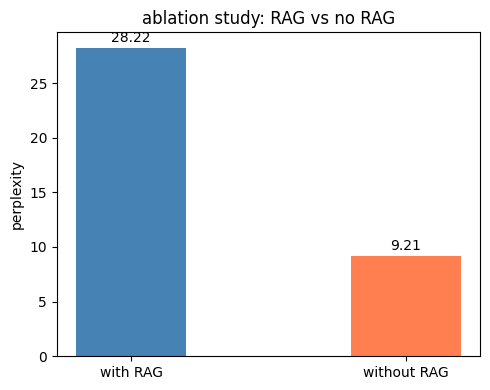

ablation plot saved


In [46]:



# RAG perplexity
rag_perplexity = 28.2241

# No-RAG perplexity
decoder_norag.load_state_dict(torch.load('/content/drive/MyDrive/Dataset/models/best_decoder_norag.pt'))
decoder_norag.eval()

total_loss = 0
total_tokens = 0

with torch.no_grad():
    for input_ids, target_ids in test_norag_loader:
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)
        logits = decoder_norag(input_ids)
        mask = (target_ids != 0)
        loss = dec_criterion(logits.reshape(-1, VOCAB_SIZE), target_ids.reshape(-1))
        total_loss += loss.item() * mask.sum().item()
        total_tokens += mask.sum().item()

norag_perplexity = math.exp(total_loss / total_tokens)

print("Ablation Study Results: ")
print(f"With RAG (retrieval)    perplexity: {rag_perplexity:.4f}")
print(f"Without RAG (baseline)  perplexity: {norag_perplexity:.4f}")
print(f"Improvement: {norag_perplexity - rag_perplexity:.4f}")


plt.figure(figsize=(5, 4))
bars = plt.bar(['with RAG', 'without RAG'], [rag_perplexity, norag_perplexity], color=['steelblue', 'coral'], width=0.4)
plt.ylabel('perplexity')
plt.title('ablation study: RAG vs no RAG')
for bar, val in zip(bars, [rag_perplexity, norag_perplexity]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.2f}', ha='center')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dataset/results/ablation_study.png')
plt.show()
print("ablation plot saved")

### Decoder Learning Curve

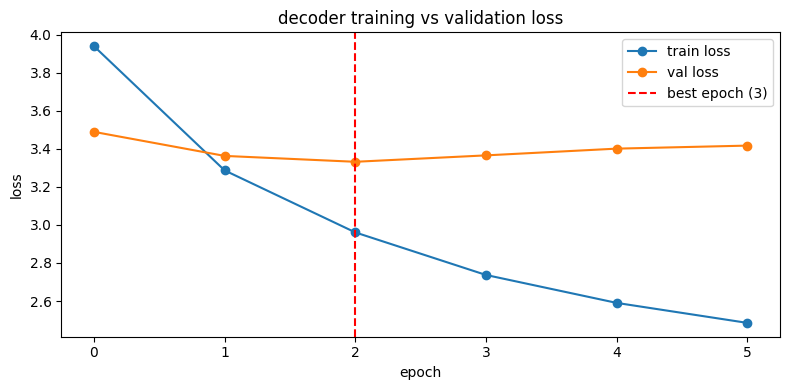

encoder saved
decoder already saved at best_decoder.pt

All files saved:
  models/best_encoder.pt
  models/best_decoder.pt
  models/best_decoder_norag.pt
  models/final_encoder.pt
  results/train_embeddings.npy
  results/test_embeddings.npy
  results/train_sentiments.npy
  results/train_texts.npy
  results/learning_curve.png
  results/evaluation_plots.png
  results/ablation_study.png
  results/decoder_learning_curve.png


In [47]:


plt.figure(figsize=(8, 4))
plt.plot(dec_train_losses, label='train loss', marker='o')
plt.plot(dec_val_losses, label='val loss', marker='o')
plt.axvline(x=best_dec_epoch-1, color='red', linestyle='--', label=f'best epoch ({best_dec_epoch})')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('decoder training vs validation loss')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dataset/results/decoder_learning_curve.png')
plt.show()



torch.save(model.state_dict(), '/content/drive/MyDrive/Dataset/models/final_encoder.pt')
print("encoder saved")
print("decoder already saved at best_decoder.pt")
print("\nAll files saved:")
print("  models/best_encoder.pt")
print("  models/best_decoder.pt")
print("  models/best_decoder_norag.pt")
print("  models/final_encoder.pt")
print("  results/train_embeddings.npy")
print("  results/test_embeddings.npy")
print("  results/train_sentiments.npy")
print("  results/train_texts.npy")
print("  results/learning_curve.png")
print("  results/evaluation_plots.png")
print("  results/ablation_study.png")
print("  results/decoder_learning_curve.png")